In [9]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
import json
import datetime

# -----------------------------
# 1. FEATURE EXTRACTION
# -----------------------------
def extract_features(texts, reference_vocab=None):
    texts = texts.dropna()
    lengths = texts.apply(lambda x: len(x.split()))

    if reference_vocab is not None:
        vec = CountVectorizer(vocabulary=reference_vocab)
        keyword_matrix = vec.transform(texts)
    else:
        vec = CountVectorizer(max_features=100, stop_words='english')
        keyword_matrix = vec.fit_transform(texts)   # FIX 1: [vec.fit](http://vec.fit)_transform → vec.fit_transform

    keyword_freq = np.asarray(keyword_matrix.sum(axis=0)).flatten()
    keyword_prob = (keyword_freq + 1e-8) / (keyword_freq.sum() + 1e-8)
    return lengths, keyword_prob, vec

# -----------------------------
# 2. DRIFT DETECTION
# -----------------------------
def check_drift(ref_lengths, ref_kw, new_lengths, new_kw,
                jsd_threshold=0.1, ks_alpha=0.05):
    ks_stat, p_value = ks_2samp(ref_lengths, new_lengths)
    length_drift = p_value < ks_alpha

    jsd = jensenshannon(ref_kw, new_kw)
    keyword_drift = jsd > jsd_threshold

    return {
        "length_drift": bool(length_drift),   # FIX 2: wrap in bool() for clean JSON serialization
        "ks_p_value": float(p_value),
        "keyword_drift": bool(keyword_drift), # FIX 2: same here
        "jsd": float(jsd)
    }

# -----------------------------
# 3. EXPLAINABILITY (KEYWORD CHANGES)
# -----------------------------
def get_top_keyword_changes(ref_kw, new_kw, vocab, top_n=10):
    delta = new_kw - ref_kw
    indices = np.argsort(np.abs(delta))[-top_n:]
    feature_names = np.array(vocab)
    changes = []
    for idx in indices:
        changes.append({
            "keyword": feature_names[idx],
            "change": float(delta[idx])
        })
    changes = sorted(changes, key=lambda x: abs(x["change"]), reverse=True)
    return changes

# -----------------------------
# 4. LOGGING
# -----------------------------
def log_drift_event(results, filename="drift_log.json"):
    log_entry = {
        "timestamp": datetime.datetime.now().isoformat(), # FIX 3: [datetime.datetime.now](http://datetime.datetime.now)() → .now().isoformat()
        "results": results
    }
    try:
        with open(filename, "a") as f:
            f.write(json.dumps(log_entry) + "\n")
    except Exception as e:
        print("Logging failed:", e)

# -----------------------------
# 5. MONITORING PIPELINE
# -----------------------------
def monitor_drift(ref_df, new_df, text_column="consumer_complaint_narrative"):

    def resolve_column(df, name, df_name):
        if name in df.columns:
            return name
        col_map = {c.lower().strip().replace(" ", "_"): c for c in df.columns}
        normalized = name.lower().strip().replace(" ", "_")
        if normalized in col_map:
            return col_map[normalized]
        raise ValueError(
            f"Column '{name}' not found in {df_name}. "
            f"Available columns: {df.columns.tolist()}"
        )

    ref_col = resolve_column(ref_df, text_column, "ref_df")
    new_col = resolve_column(new_df, text_column, "new_df")

    ref_lengths, ref_kw, vec = extract_features(ref_df[ref_col])
    new_lengths, new_kw, _ = extract_features(
        new_df[new_col],
        reference_vocab=vec.vocabulary_
    )

    results = check_drift(ref_lengths, ref_kw, new_lengths, new_kw)

    if results["keyword_drift"]:
        vocab_list = sorted(vec.vocabulary_, key=vec.vocabulary_.get)
        changes = get_top_keyword_changes(ref_kw, new_kw, vocab_list)
        results["top_keyword_changes"] = changes

    if results["length_drift"] or results["keyword_drift"]:
        print("⚠️ Drift detected!")
        print(results)
        log_drift_event(results)
    else:
        print("✅ No significant drift detected.")

    return results

# -----------------------------
# 6. EXAMPLE USAGE
# -----------------------------
if __name__ == "__main__":
    ref_df = pd.read_parquet("cfpb_stage1.parquet")  # FIX 5: [pd.read](http://pd.read)_parquet → pd.read_parquet
    new_df = pd.read_parquet("cfpb2_new.parquet")    # FIX 5: same here
    results = monitor_drift(ref_df, new_df)

⚠️ Drift detected!
{'length_drift': True, 'ks_p_value': 5.590089360981336e-07, 'keyword_drift': True, 'jsd': 0.21820001526022872, 'top_keyword_changes': [{'keyword': 'xxxx', 'change': -0.11282805398315005}, {'keyword': 'xx', 'change': 0.030107517559017596}, {'keyword': 'account', 'change': 0.018839034390250545}, {'keyword': 'consumer', 'change': -0.0162671390802308}, {'keyword': 'debt', 'change': 0.014666647066091968}, {'keyword': '00', 'change': 0.01446011231130912}, {'keyword': 'dispute', 'change': 0.014137968817731609}, {'keyword': 'card', 'change': 0.013172106423098393}, {'keyword': 'report', 'change': -0.0106777464515264}, {'keyword': 'information', 'change': -0.01055686326928747}]}


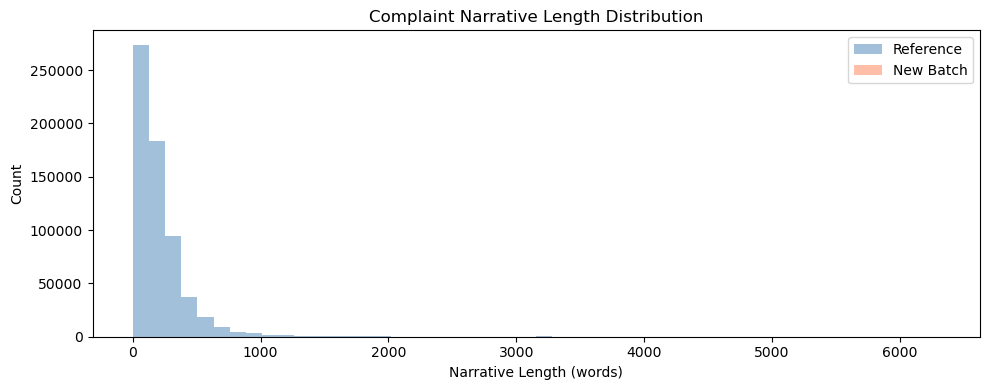

In [11]:
import matplotlib.pyplot as plt

col = "Consumer complaint narrative"

ref_lengths, _, _ = extract_features(ref_df[col])
new_lengths, _, _ = extract_features(new_df[col])

plt.figure(figsize=(10, 4))
plt.hist(ref_lengths, bins=50, alpha=0.5, label='Reference', color='steelblue')
plt.hist(new_lengths, bins=50, alpha=0.5, label='New Batch', color='coral')
plt.xlabel("Narrative Length (words)")
plt.ylabel("Count")
plt.title("Complaint Narrative Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()